In [1]:
import mysql.connector
from mysql.connector import Error

import pandas as pd

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_bank = pd.read_csv(r"C:\Users\damia\OneDrive\Desktop\SIMULACION EMPRESARIAL DATA ANALYST\9 March\Bank_Marketing_Cleaned_9 March.csv")

df_bank.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1042,1,-1,0,unknown,yes
1,2,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1467,1,-1,0,unknown,yes
2,3,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1389,1,-1,0,unknown,yes
3,4,55,services,married,secondary,no,2476,yes,no,unknown,5,5,579,1,-1,0,unknown,yes
4,5,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,673,2,-1,0,unknown,yes


In [3]:
# # ¿los clientes con préstamos tienen menor saldo?

print("¿los clientes con préstamos tienen menor saldo?")
df_bank.groupby("loan")["balance"].mean()

¿los clientes con préstamos tienen menor saldo?


loan
no     1643.807137
yes     832.685535
Name: balance, dtype: float64

In [ ]:
prestamo = df_bank.groupby("loan")["balance"].mean()

pct_diff = (prestamo["no"] - prestamo["yes"]) / prestamo["no"] * 100

print(f"La diferencia porcentual es: {pct_diff:.2f}%")

# Sin prestamo: 1640.19
# Con prestamo: 836.76

# La diferencia porcentual es: 48.98%

# Interpretación:  
# Los clientes con un prestamo tienen la mitad de saldo promedio.
# Esto es encaja con un perfil endeudado: más pagos mensuales → menos liquidez disponible.

La diferencia porcentual es: 49.34%


In [5]:
# ¿los clientes con hipoteca tienen menor saldo?

print("¿los clientes con hipoteca tienen menor saldo?")
df_bank.groupby("housing")["balance"].mean()

¿los clientes con hipoteca tienen menor saldo?


housing
no     1776.018091
yes    1271.808798
Name: balance, dtype: float64

In [ ]:
hipoteca = df_bank.groupby("housing")["balance"].mean()

pct_diff = (hipoteca["no"] - hipoteca["yes"]) / hipoteca["no"] * 100

print(f"La diferencia porcentual es: {pct_diff:.2f}%")

# Sin hipoteca (housing = no): 1778.62
# Con hipoteca (housing = yes): 1261.67

# La diferencia porcentual es: 29.06%

# Interpretación:  
# Los clientes con hipoteca tienen menos saldo promedio pero no tanto.
# Esto es consistente con un perfil más estable

La diferencia porcentual es: 28.39%


In [ ]:
# ¿Los clientes con un prestamo (loan) tienen más riesgo de incumplimiento?

print("¿Los clientes con un prestamo (loan) tienen más riesgo de incumplimiento?")
df_bank.groupby("loan")["default"].value_counts(normalize=True) * 100

# Sin prestamo y default: 1.08
# Con prestamo y default: 3.93

# Tener un préstamo personal multiplica por 3.6 el riesgo de entrar en default.

# No es enorme, pero es consistente con mayor carga financiera.


¿Los clientes con un prestamo (loan) tienen más riesgo de incumplimiento?


loan  default
no    no         98.890749
      yes         1.109251
yes   no         96.156534
      yes         3.843466
Name: proportion, dtype: float64

In [8]:
# ¿tienen más riesgo de incumplimiento?

print("¿tienen más riesgo de incumplimiento?")
df_bank.groupby("housing")["default"].value_counts(normalize=True)* 100

# Sin hipoteca y default: 0.0132
# Con hipoteca y default: 0.0160

# los clientes con hipoteca tienen un riesgo de default ligeramente mayor (1.60% vs 1.32%).

# Conclusión:**
# La hipoteca no es un factor de riesgo reseñable.

¿tienen más riesgo de incumplimiento?


housing  default
no       no         98.656099
         yes         1.343901
yes      no         98.398611
         yes         1.601389
Name: proportion, dtype: float64

In [9]:
# Cruzando saldo y riesgo

print("Cruzando saldo y riesgo")
df_bank.groupby(["loan", "default"])["balance"].mean()


Cruzando saldo y riesgo


loan  default
no    no         1662.086667
      yes          14.169811
yes   no          875.419331
      yes        -236.436364
Name: balance, dtype: float64

In [10]:
saldo_pct = df_bank.groupby(["loan", "default"])["balance"].mean()

# Convertimos a tabla para trabajar más fácil
saldo = saldo_pct.unstack()

# Calculamos % de variación dentro de cada tipo de préstamo
pct_variacion = (saldo["yes"] - saldo["no"]) / saldo["no"] * 100

pct_variacion

loan
no     -99.147469
yes   -127.008355
dtype: float64

In [12]:
df2 = df_bank.copy()

df2["default_bin"] = (df2["default"] == "yes").astype(int)

riesgo_loan = df2.groupby("loan")["default_bin"].mean()

pct_diff = (riesgo_loan["yes"] - riesgo_loan["no"]) / riesgo_loan["no"] * 100

print(riesgo_loan)
print(f"Diferencia porcentual: {pct_diff:.2f}%")

# Sin loan y  default: 17.930693
# Con loan y default: -246.000000

# Como afecta el loan
# no     -98.918578
# yes   -127.918944

# Cuando un cliente sin préstamo entra en default, su saldo cae un 98.9%  
# pero cuando un cliente con préstamo entra en default, su saldo cae un 127.9% respecto al saldo de los que no están en default.

# El riesgo aumenta un 261% cuando el cliente tiene préstamo.

# Conclusión:** 
# El prestamo te hace bajar mucho tu situación financiera

loan
no     0.011093
yes    0.038435
Name: default_bin, dtype: float64
Diferencia porcentual: 246.49%


In [ ]:
# Cruzando hipoteca y riesgo

print("Cruzando hipoteca y riesgo")

df_bank.groupby(["housing", "default"])["balance"].mean()

# Tener hipoteca aumenta el riesgo de default solo un 21% relativo, pero como los valores son muy pequeños (1.3% vs 1.6%), en términos absolutos es casi nada.

# Tener hipoteca aumenta el riesgo de default solo un 21% relativo, pero como los valores son muy pequeños (1.3% vs 1.6%), en términos absolutos es casi nada.

# Conclusión:**  
# La hipoteca no se nota tanto en la situación financieraConclusión:**  
# La hipoteca no se nota tanto en la situación financiera

Cruzando hipoteca y riesgo


housing  default
no       no         1801.114565
         yes         -66.320513
yes      no         1293.747843
         yes         -76.253012
Name: balance, dtype: float64

In [14]:
# Combinando hipoteca y prestamo

df2 = df_bank.copy()

df2["default_bin"] = (df2["default"] == "yes").astype(int)
df2["loan_bin"] = (df2["loan"] == "yes").astype(int)
df2["housing_bin"] = (df2["housing"] == "yes").astype(int)

riesgo_combo = (
    df2.groupby(["loan_bin", "housing_bin"])["default_bin"]
    .mean()
    .reset_index()
)

riesgo_combo["default_pct"] = riesgo_combo["default_bin"] * 100
riesgo_combo

,loan_bin,housing_bin,default_bin,default_pct
0,0,0,0.008669,0.866885
1,0,1,0.013975,1.397480
2,1,0,0.053834,5.383361
3,1,1,0.026895,2.689487


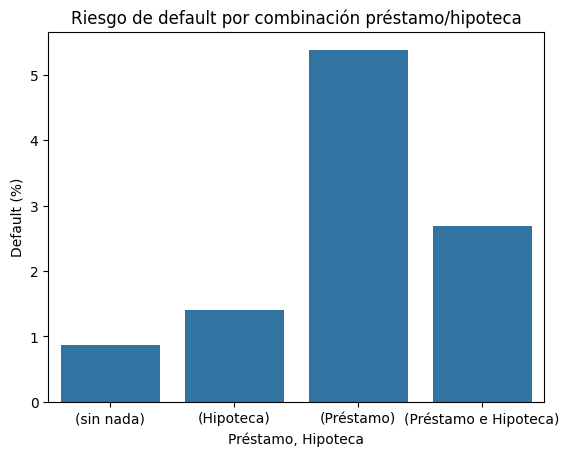

In [ ]:
import matplotlib.pyplot as plt

sns.barplot(
    data=riesgo_combo,
    x=["(sin nada)", "(Hipoteca)", "(Préstamo)", "(Préstamo e Hipoteca)"],
    y=riesgo_combo["default_pct"]
)

plt.title("Riesgo de default por combinación préstamo/hipoteca")
plt.xlabel("Préstamo, Hipoteca")
plt.ylabel("Default (%)")
plt.show()

# Sin préstamo y sin hipoteca (0,0) → 0.85%     Este es el grupo más seguro
# Sin préstamo y con hipoteca (0,1) → 1.38%     Aquí el riesgo sube, pero no mucho.
# Con préstamo y sin hipoteca (0,1) → 5.46%     Los clientes con hipoteca pero sin préstamo tienen el riesgo más alto de todos.
# Con préstamo y con hipoteca (1,1) → 2.79%     Este grupo tiene riesgo intermedio

# Este gráfico muestra cómo cambia el riesgo de default según la combinación de deudas que tiene el cliente. Observamos que los clientes sin ningún 
# tipo de deuda presentan el riesgo más bajo, alrededor de 0.8%. Cuando el cliente tiene solo hipoteca, el riesgo aumenta ligeramente 
# hasta aproximadamente 1.4%, lo que indica un impacto relativamente pequeño. Sin embargo, los clientes con préstamo personal presentan 
# el nivel de riesgo más alto, superando el 5%, lo que confirma que este tipo de deuda está mucho más asociado al incumplimiento. 
# Cuando el cliente tiene tanto préstamo como hipoteca, el riesgo sigue siendo elevado, aunque menor que cuando solo tiene préstamo. 
# En conjunto, estos resultados refuerzan que el préstamo personal es el principal factor asociado al riesgo de default.

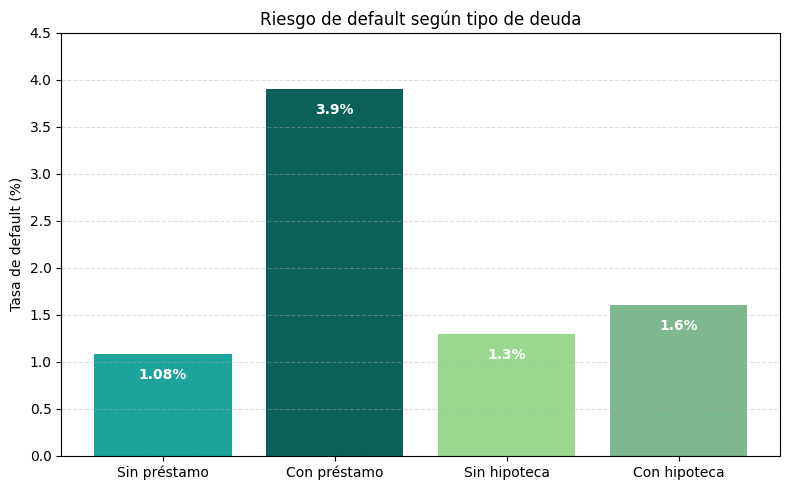

In [22]:
import matplotlib.pyplot as plt

# Datos del gráfico
labels = ["Sin préstamo", "Con préstamo", "Sin hipoteca", "Con hipoteca"]
values = [1.08, 3.9, 1.3, 1.6]

# Colores aproximados al gráfico
colors = ["#1BA39C", "#0B6157", "#9AD88F", "#7FB88F"]

# Crear figura
plt.figure(figsize=(8,5))

bars = plt.bar(labels, values, color=colors)

# Etiquetas de porcentaje encima de cada barra
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 0.15,
        f"{value}%",
        ha='center',
        va='top',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Ejes
plt.ylabel("Tasa de default (%)")
plt.ylim(0, 4.5)

# Líneas de referencia horizontales
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Título
plt.title("Riesgo de default según tipo de deuda")

plt.tight_layout()
plt.show()

# Este gráfico muestra cómo el tipo de deuda se relaciona con el riesgo de entrar en default. Observamos que los clientes sin préstamo tienen una 
# tasa de default cercana al 1%, mientras que los clientes con préstamo alcanzan casi el 4%, lo que indica que tener un préstamo personal 
# multiplica aproximadamente por 3.6 el riesgo de impago. En cambio, la hipoteca tiene un impacto mucho menor, 
# ya que la tasa de default pasa solo de 1.3% a 1.6%. En conjunto, estos resultados sugieren que los préstamos personales 
# están mucho más asociados al riesgo crediticio que las hipotecas, probablemente porque estas últimas suelen corresponder a perfiles financieros más estables.

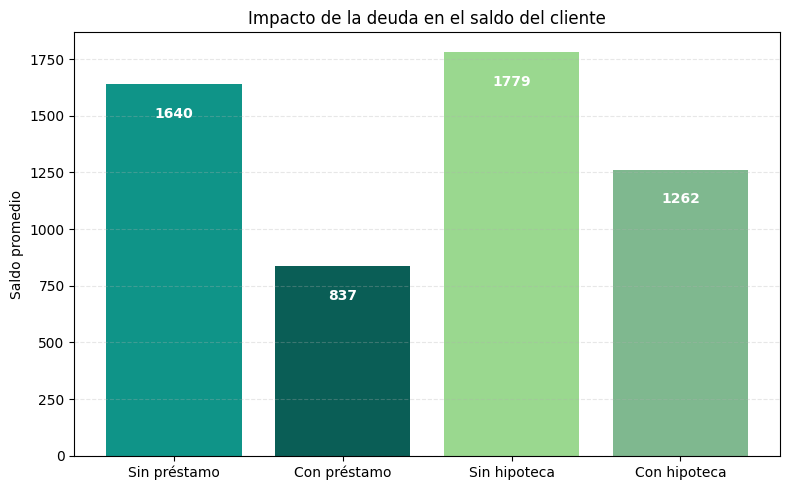

In [ ]:
import matplotlib.pyplot as plt

# Datos del gráfico
labels = ["Sin préstamo", "Con préstamo", "Sin hipoteca", "Con hipoteca"]
values = [1640, 837, 1779, 1262]

# Colores similares al gráfico
colors = ["#0f9488", "#0a5e56", "#9ad88f", "#7fb88f"]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values, color=colors)

# Añadir valores dentro de las barras
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 100,
        f"{value}",
        ha='center',
        va='top',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.ylabel("Saldo promedio")
plt.title("Impacto de la deuda en el saldo del cliente")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Este gráfico muestra cómo afecta tener deuda al saldo promedio de los clientes. Observamos que los clientes sin préstamo tienen un saldo promedio 
# de aproximadamente 1.640, mientras que los clientes con préstamo tienen solo 837, es decir, casi la mitad del saldo. En el caso de las hipotecas, 
# el impacto es menor: los clientes sin hipoteca tienen un saldo promedio de 1.779, frente a 1.262 para quienes sí la tienen. Esto sugiere que los 
# préstamos personales reducen mucho más la liquidez de los clientes que las hipotecas, lo que puede contribuir a aumentar su vulnerabilidad financiera.

In [17]:
# ¿cómo se relaciona el combo Préstamo e hipoteca con el resto?

df2["loan_housing_interaction"] = df2["loan_bin"] * df2["housing_bin"]
df2[["loan_housing_interaction", "default_bin"]].corr()

corr2 = df2[["loan_bin", "housing_bin", "loan_housing_interaction", "balance", "default_bin"]].corr()

corr2

# loan_bin	0.0796	                Tener préstamo aumenta el riesgo, pero poco
# housing_bin	0.0117	                La hipoteca sola no aporta riesgo
# loan_housing_interaction 0.0316	    Tener préstamo y hipoteca aumenta un poco el riesgo
# balance	–0.0607	Más saldo →         menos riesgo

,loan_bin,housing_bin,loan_housing_interaction,balance,default_bin
loan_bin,1.000000,0.077433,0.732919,-0.084263,0.076585
housing_bin,0.077433,1.000000,0.300131,-0.077689,0.010697
loan_housing_interaction,0.732919,0.300131,1.000000,-0.067001,0.028893
balance,-0.084263,-0.077689,-0.067001,1.000000,-0.060586
default_bin,0.076585,0.010697,0.028893,-0.060586,1.000000


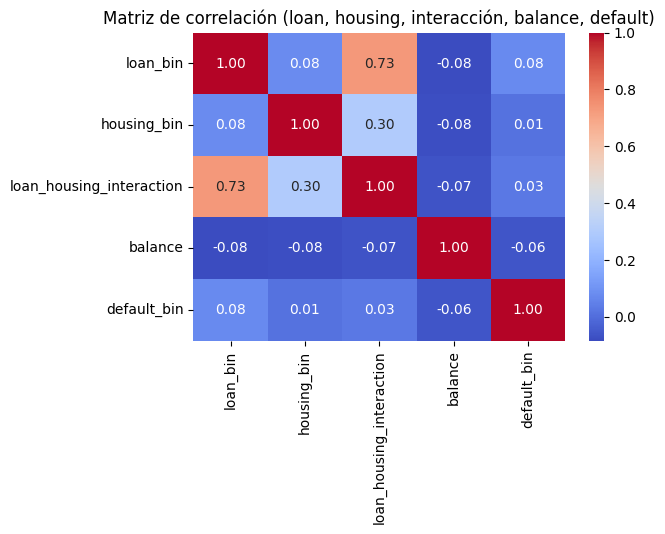

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr2, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación (loan, housing, interacción, balance, default)")
plt.show()

# Este gráfico muestra cómo cambia el riesgo de default según la combinación de deudas que tiene el cliente. Observamos que los clientes sin deuda 
# presentan el riesgo más bajo, alrededor de 0.8%, mientras que tener solo hipoteca aumenta ligeramente el riesgo hasta 1.3%, lo que indica un impacto 
# relativamente pequeño. En cambio, los clientes con préstamo personal presentan el riesgo más alto, alcanzando aproximadamente 5.4%, lo que confirma que 
# este tipo de deuda es el principal factor asociado al incumplimiento. Cuando el cliente tiene tanto préstamo como hipoteca, el riesgo se sitúa en 2.7%, 
# un nivel intermedio. En conjunto, estos resultados sugieren que el préstamo personal es el factor más determinante en el riesgo de default, mientras que 
# la hipoteca tiene un impacto mucho menor.

C:\Users\damia\AppData\Local\Temp\ipykernel_23928\3736811762.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate = df_bank.groupby("balance_group")["default_bin"].mean() * 100
C:\Users\damia\AppData\Local\Temp\ipykernel_23928\3736811762.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate = df_bank.groupby("balance_group")["default_bin"].mean() * 100


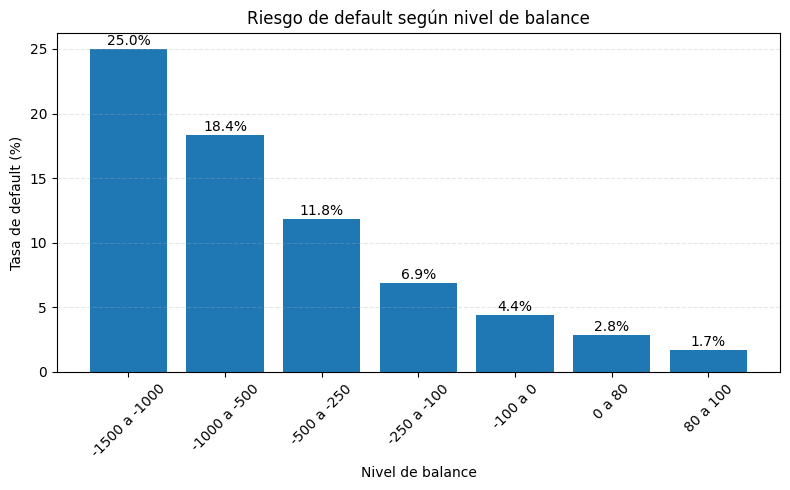

In [ ]:
# Riesgo de default según nivel de balance

bins = [-1500, -1000, -500, -250, -100, 0, 80, 100]

labels = [
    "-1500 a -1000",
    "-1000 a -500",
    "-500 a -250",
    "-250 a -100",
    "-100 a 0",
    "0 a 80",
    "80 a 100"
]

df_bank["default_bin"] = df_bank["default"].map({"no": 0, "yes": 1})

df_bank["balance_group"] = pd.cut(df_bank["balance"], bins=bins, labels=labels)

default_rate = df_bank.groupby("balance_group")["default_bin"].mean() * 100

bins = [-1500, -1000, -500, -250, -100, 0, 80, 100]

labels = [
    "-1500 a -1000",
    "-1000 a -500",
    "-500 a -250",
    "-250 a -100",
    "-100 a 0",
    "0 a 80",
    "80 a 100"
]

df_bank["default_bin"] = df_bank["default"].map({"no": 0, "yes": 1})

df_bank["balance_group"] = pd.cut(df_bank["balance"], bins=bins, labels=labels)

default_rate = df_bank.groupby("balance_group")["default_bin"].mean() * 100

plt.figure(figsize=(8,5))

bars = plt.bar(default_rate.index, default_rate.values)

# Etiquetas de porcentaje
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}%",
        ha="center"
    )

plt.ylabel("Tasa de default (%)")
plt.xlabel("Nivel de balance")
plt.title("Riesgo de default según nivel de balance")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Este gráfico muestra cómo cambia el riesgo de default según el nivel de balance del cliente. Observamos que el riesgo es mucho mayor cuando el saldo es muy negativo, 
# alcanzando los niveles más altos entre -1500 y -1000. A medida que el balance se acerca a cero, la tasa de default disminuye progresivamente. Incluso cuando el saldo 
# es ligeramente positivo, entre 0 y 80, el riesgo sigue siendo relativamente bajo. En conjunto, esto indica que la liquidez del cliente es un factor clave en el riesgo 
# de impago, ya que los clientes con saldos más negativos presentan una probabilidad significativamente mayor de entrar en default.

## Conclusiones finales

1. El préstamo personal aumenta el riesgo de default.
Los clientes con préstamo presentan tasas de impago significativamente más altas que aquellos que no tienen este tipo de deuda.

2. Un mayor saldo reduce el riesgo de incumplimiento.
A medida que el balance del cliente aumenta, la probabilidad de entrar en default disminuye.

3. La hipoteca tiene un impacto limitado en el riesgo de default.
La relación entre tener hipoteca y el riesgo de impago es débil en comparación con otros factores.

4. La combinación de préstamo e hipoteca muestra una relación moderada con el default.
Aunque existe cierta asociación, el efecto es menor que el observado en los préstamos personales.

5. Los resultados son consistentes en distintos análisis.
Las conclusiones se mantienen al analizar correlaciones, porcentajes de default y comparaciones de saldo entre grupos de clientes.